## 1️⃣ Import Libraries
Import all libraries required for normalization, dimensionality
reduction, batch correction, and visualization.

In [ ]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import harmonypy as hm

sc.settings.verbosity = 3
sc.settings.figdir = "../figures/"
sc.set_figure_params(dpi=100, facecolor="white")

## 2️⃣ Load QC-Filtered Data
Load the quality-controlled AnnData object saved at the end of Script 02.
This object contains 29,287 high-quality cells across 40 kidney samples,
ready for normalization and dimensionality reduction.

In [ ]:
adata = sc.read_h5ad("../data/processed/GSE279086_qc_filtered.h5ad")
print(adata)
print(f"\nCells : {adata.shape[0]:,}")
print(f"Genes : {adata.shape[1]:,}")
print(f"Samples: {adata.obs['sample'].nunique()}")

## 3️⃣ Normalize and Log-Transform
Normalize raw UMI counts to account for differences in sequencing depth
across cells, then apply log1p transformation to compress the expression
scale and reduce the influence of highly expressed genes.

### Steps:
- **Normalize per cell** — scale each cell to a total count of 10,000
  (counts per 10K, CP10K), making cells directly comparable
- **Log1p transform** — apply log(x+1) to normalize the distribution;
  the +1 prevents log(0) errors for genes with zero counts

### Why 10,000?
10,000 is the standard target sum in scanpy — it approximates the
median library size in most scRNA-seq datasets and is directly
comparable to Seurat's `NormalizeData()` default.

### Raw counts are preserved:
Raw counts are stored in `adata.layers['counts']` before normalization
so they can be retrieved for DEG analysis which requires raw counts.

In [ ]:
# Store raw counts before normalization
adata.layers['counts'] = adata.X.copy()

# Normalize to 10,000 counts per cell
sc.pp.normalize_total(adata, target_sum=1e4)

# Log1p transform
sc.pp.log1p(adata)

print("✅ Normalization and log1p transformation complete")
print(f"\nadata.layers keys : {list(adata.layers.keys())}")
print(f"adata.X min value : {adata.X.min():.4f}")
print(f"adata.X max value : {adata.X.max():.4f}")

## 4️⃣ Identify Highly Variable Genes (HVGs)
Select the most informative genes for downstream analysis by identifying
genes that vary significantly across cells. Using all 36,601 genes would
add noise and slow computation — HVGs capture the biological signal.

### Method:
- **flavor='seurat_v3'** — uses raw counts (from `layers['counts']`)
  to identify HVGs, consistent with Seurat v3/v5 methodology
- **n_top_genes=2000** — top 2,000 most variable genes selected,
  standard for datasets of this size
- **batch_key='sample'** — HVGs are identified per sample then
  aggregated, preventing batch-specific genes from dominating

### Why batch_key matters:
Without `batch_key`, genes that vary only because of technical
differences between samples would be selected as HVGs — corrupting
downstream PCA and clustering with batch effects.

In [ ]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor='seurat',
    batch_key='sample',
    subset=False
)

print(f"Total genes         : {adata.shape[1]:,}")
print(f"Highly variable     : {adata.var['highly_variable'].sum():,}")
print(f"Non-variable        : {(~adata.var['highly_variable']).sum():,}")

sc.pl.highly_variable_genes(adata, show=False)
plt.tight_layout()
plt.savefig("../figures/HVGs.png", dpi=100, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/HVGs.png")

## 5️⃣ Scale Data and Run PCA
Scale the normalized expression data and perform Principal Component
Analysis (PCA) to reduce dimensionality from 2,000 HVGs to 50 principal
components that capture the maximum biological variance.

### Steps:
- **Scale** — center each gene to mean=0 and variance=1 across all cells
  so that highly expressed genes don't dominate PCA. Scaling is applied
  only to the 2,000 HVGs to conserve memory.
- **PCA** — compress 2,000 HVGs into 50 principal components;
  each PC captures a different axis of biological variation
- **Elbow plot** — visualize variance explained per PC to determine
  how many PCs carry meaningful biological signal

### Why 50 PCs?
50 PCs is the standard starting point. The elbow plot shows where

In [ ]:
# Extract HVG names
hvg_genes = adata.var_names[adata.var['highly_variable']]

# Scale only HVG subset to conserve memory
adata_hvg = adata[:, hvg_genes].copy()
sc.pp.scale(adata_hvg, max_value=10)

# Run PCA on scaled HVGs
sc.tl.pca(adata_hvg, n_comps=50)

# Store PCA results back in main adata
adata.obsm['X_pca'] = adata_hvg.obsm['X_pca']
adata.uns['pca']    = adata_hvg.uns['pca']

# Free memory
del adata_hvg

print("✅ Scaling and PCA complete")
print(f"PCA shape: {adata.obsm['X_pca'].shape}")

# Elbow plot
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=False, show=False)
plt.title("PCA Elbow Plot — Variance Explained per PC", fontsize=14, fontweight='bold')
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.tight_layout()
plt.savefig("../figures/PCA_elbow.png", dpi=100, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/PCA_elbow.png")

## 6️⃣ Harmony Batch Correction
Apply Harmony batch correction to the PCA embedding to remove technical
variation introduced by processing 40 samples across different batches.

### Why Harmony?
Without batch correction, cells from the same cell type but different
samples would cluster separately due to technical differences rather
than biology. Harmony adjusts the PCA coordinates so that:
- Cells cluster by **cell type** ✅
- Cells do NOT cluster by **sample or batch** ✅

### How Harmony Works:
1. Takes the first 30 PCs from the PCA embedding (29,287 cells × 30 PCs)
2. Iteratively adjusts PC coordinates per sample until convergence
3. Returns a corrected embedding stored in `adata.obsm['X_harmony']`
4. Original PCA is preserved in `adata.obsm['X_pca']`

### Important:
Harmony corrects the **embedding only** — it does not modify
the gene expression values in `adata.X`. All downstream steps
(UMAP, clustering, neighbors) use `X_harmony` instead of `X_pca`.

In [ ]:
import harmonypy as hm

# Use first 30 PCs
pca_30 = adata.obsm['X_pca'][:, :30]

# Run Harmony directly
harmony_out = hm.run_harmony(
    pca_30,
    adata.obs,
    'sample',
    max_iter_harmony=30
)

# Store corrected embedding
adata.obsm['X_harmony'] = harmony_out.Z_corr

print("✅ Harmony batch correction complete")
print(f"Harmony embedding shape: {adata.obsm['X_harmony'].shape}")
print(f"Converged in           : {len(harmony_out.objective_harmony)} iterations")

## 7️⃣ Compute Neighbors and UMAP
Build a nearest neighbor graph from the Harmony-corrected embedding
and generate a UMAP visualization to inspect the global structure
of the dataset.

### Steps:
- **Neighbors** — for each cell, find its 30 most similar cells
  in the 30-dimensional Harmony space. This builds a graph where
  cells are connected to their nearest neighbors — the foundation
  for both clustering and UMAP.
- **UMAP** — projects the 30D neighbor graph into 2D for visualization.
  Cells that are similar in 30D space appear close together in 2D.

### Key Parameters:
- `n_neighbors=30` — how many neighbors each cell connects to;
  higher values capture more global structure
- `n_pcs=30` — use all 30 Harmony-corrected PCs
- `use_rep='X_harmony'` — use Harmony embedding, not raw PCA

### Remember:
UMAP is for **visualization only** — clustering happens in the
next step using the same neighbor graph in 30D Harmony space.

In [ ]:
# Build neighbor graph using Harmony embedding
sc.pp.neighbors(
    adata,
    n_neighbors=30,
    n_pcs=30,
    use_rep='X_harmony'
)

# Compute UMAP
sc.tl.umap(adata, min_dist=0.3)

print("✅ Neighbors and UMAP complete")
print(f"UMAP shape: {adata.obsm['X_umap'].shape}")

# Plot both UMAPs side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — colored by sample
sc.pl.umap(
    adata,
    color='sample',
    title='UMAP — Colored by Sample',
    legend_loc='right margin',
    legend_fontsize=6,
    ax=axes[0],
    show=False
)

# Plot 2 — colored by disease
sc.pl.umap(
    adata,
    color='disease',
    title='UMAP — Colored by Disease',
    legend_loc='right margin',
    ax=axes[1],
    show=False
)

plt.tight_layout()
plt.savefig("../figures/UMAP_sample_disease.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/UMAP_sample_disease.png")

# Plot UMAP colored by disease
sc.pl.umap(
    adata,
    color='disease',
    title='UMAP — Colored by Disease',
    show=False
)
plt.tight_layout()
plt.savefig("../figures/UMAP_by_disease.png", dpi=100, bbox_inches='tight')
plt.show()

print("✅ Saved: figures/UMAP_by_sample.png")
print("✅ Saved: figures/UMAP_by_disease.png")

## 8️⃣ Leiden Clustering
Cluster cells into groups based on their similarity in the
Harmony-corrected 30D embedding using the Leiden algorithm.

### Why Leiden over Louvain?
Leiden is the modern successor to Louvain clustering:
- Produces better connected communities
- Faster convergence
- Guaranteed well-connected clusters
- Now the standard in scanpy workflows

### Resolution Parameter:
- Controls the number of clusters
- **Low resolution (0.2–0.4)** → fewer, broader clusters
- **High resolution (0.8–1.5)** → more, finer clusters
- We start with **resolution=0.5** — a balanced starting point
- Can be tuned after inspecting the UMAP

### Important:
Clustering operates on the **neighbor graph in 30D Harmony space**
— not on the 2D UMAP. UMAP is only used for visualization.

/tmp/ipykernel_2407/1951893775.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5, random_state=42)


running Leiden clustering
    finished: found 21 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:14)
✅ Leiden clustering complete
Number of clusters: 21

Cells per cluster:
leiden
0     3824
1     3502
2     2513
3     2368
4     2343
5     2176
6     1707
7     1681
8     1364
9     1350
10    1299
11    1068
12    1032
13     748
14     607
15     605
16     495
17     256
18     127
19     124
20      98
Name: count, dtype: int64


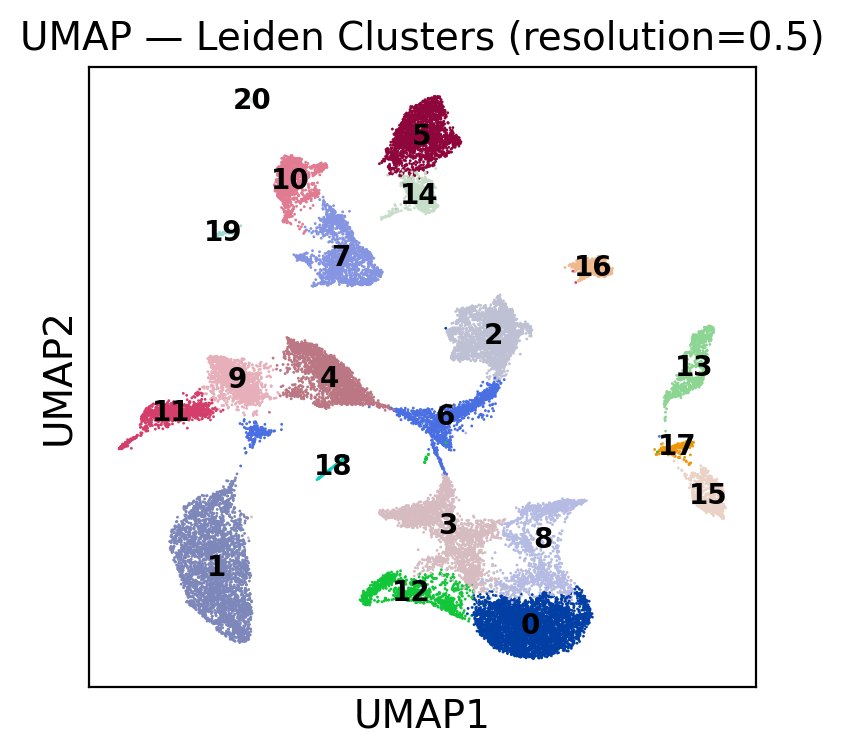

✅ Saved: figures/UMAP_leiden_clusters.png


In [15]:
# Run Leiden clustering
sc.tl.leiden(adata, resolution=0.5, random_state=42)

# Summary
n_clusters = adata.obs['leiden'].nunique()
print(f"✅ Leiden clustering complete")
print(f"Number of clusters: {n_clusters}")
print(f"\nCells per cluster:")
print(adata.obs['leiden'].value_counts().sort_index())

# Plot UMAP colored by cluster
sc.pl.umap(
    adata,
    color='leiden',
    title=f'UMAP — Leiden Clusters (resolution=0.5)',
    legend_loc='on data',
    legend_fontsize=10,
    show=False
)
plt.tight_layout()
plt.savefig("../figures/UMAP_leiden_clusters.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: figures/UMAP_leiden_clusters.png")

## 9️⃣ Save Processed AnnData Object
Save the fully processed AnnData object to disk. This object contains
all results from normalization, HVG selection, PCA, Harmony batch
correction, UMAP, and Leiden clustering — ready for cell type
annotation in Script 04.

### What is saved:
- `adata.X` — log-normalized expression matrix
- `adata.layers['counts']` — raw UMI counts for DEG analysis
- `adata.obsm['X_pca']` — PCA embedding (50 PCs)
- `adata.obsm['X_harmony']` — Harmony corrected embedding (30 PCs)
- `adata.obsm['X_umap']` — UMAP coordinates (2D)
- `adata.obs['leiden']` — cluster labels

In [18]:
import os

out_path = "../data/processed/GSE279086_processed.h5ad"
adata.write_h5ad(out_path)

size_mb = os.path.getsize(out_path) / (1024 * 1024)

print(f"✅ Saved: {out_path}")
print(f"   Cells   : {adata.shape[0]:,}")
print(f"   Genes   : {adata.shape[1]:,}")
print(f"   Clusters: {adata.obs['leiden'].nunique()}")
print(f"   Size    : {size_mb:.1f} MB")
print(f"\nadata summary:")
print(adata)

✅ Saved: ../data/processed/GSE279086_processed.h5ad
   Cells   : 29,287
   Genes   : 36,601
   Clusters: 21
   Size    : 935.4 MB

adata summary:
AnnData object with n_obs × n_vars = 29287 × 36601
    obs: 'sample', 'disease', 'GSM', 'tissue', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'sample_colors', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'disease_colors', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_pca_30', 'X_harmony', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'
